# Docling Provider POC (Structured Extraction + Bounding Boxes)

Goal: validate whether Docling can be used as a backend adapter (alternative to ACU) while preserving a provider-agnostic output contract for the frontend.

This POC checks:
- Structured extraction using Docling template extraction
- Availability of provenance bounding boxes
- Feasibility of shaping Docling output into an ACU-like field contract


## 1) Environment and sample input


In [22]:
from pathlib import Path
import os
import json
import tempfile
from pydantic import BaseModel, Field

repo_root = Path.cwd()
sample_pdf = repo_root / "data" / "AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf"
assert sample_pdf.exists(), f"Sample PDF missing: {sample_pdf}"
print("Repo root:", repo_root)
print("Sample PDF:", sample_pdf)


Repo root: c:\Users\deril\OneDrive\Desktop\Deril\Development\Azure\Intelligent-Document-Processing-Production-Ready
Sample PDF: c:\Users\deril\OneDrive\Desktop\Deril\Development\Azure\Intelligent-Document-Processing-Production-Ready\data\AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf


## 2) Install/Import Docling

If imports fail, run this once in your environment:

`pip install "docling[vlm]"`


In [23]:
from docling.datamodel.base_models import InputFormat
from docling.document_extractor import DocumentExtractor
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption

print("Docling imports OK")

from pydantic import BaseModel, Field


Docling imports OK


## 2b) GPU validation (Torch + Docling conversion)

This section checks CUDA visibility and runs a CPU vs CUDA conversion timing test.
Use `nvidia-smi -l 1` in a separate terminal while running this cell.


In [24]:
# import time
# import torch

# from docling.datamodel.accelerator_options import AcceleratorOptions, AcceleratorDevice

# print("Torch version:", torch.__version__)
# print("Torch CUDA version:", torch.version.cuda)
# print("CUDA available:", torch.cuda.is_available())
# if torch.cuda.is_available():
#     print("GPU:", torch.cuda.get_device_name(0))

# def _time_convert(device: AcceleratorDevice):
#     pipeline_options = PdfPipelineOptions()
#     pipeline_options.accelerator_options = AcceleratorOptions(
#         device=device,
#         num_threads=8,
#     )

#     conv = DocumentConverter(
#         format_options={
#             InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
#         }
#     )

#     t0 = time.perf_counter()
#     _ = conv.convert(str(sample_pdf))
#     dt = time.perf_counter() - t0
#     return dt

# cpu_time = _time_convert(AcceleratorDevice.CPU)
# print(f"CPU convert time: {cpu_time:.2f}s")

# if torch.cuda.is_available():
#     # warmup
#     _ = _time_convert(AcceleratorDevice.CUDA)
#     cuda_time = _time_convert(AcceleratorDevice.CUDA)
#     print(f"CUDA convert time: {cuda_time:.2f}s")
#     speedup = cpu_time / cuda_time if cuda_time > 0 else float('inf')
#     print(f"Speedup (CPU/CUDA): {speedup:.2f}x")
# else:
#     print("CUDA not available in this Python environment.")

# print('Tip: monitor GPU with `nvidia-smi -l 1` for process/memory/utilization.')


## 3) Pass 1 Extraction (raw-only, stable schema)

Pass 1 focuses on raw anchor fields only. Keep fields optional and concise to reduce hallucinated outputs.


In [34]:
from typing import Optional

class LicenseAgreementPass1RawTemplate(BaseModel):
    DocumentName_raw: Optional[str] = Field(
        default="",
        description="Official agreement title, verbatim from the document."
    )
    Parties_raw: Optional[str] = Field(
        default="",
        description="Party names as written, including aliases in quotes/parentheses when present."
    )
    AgreementDate_raw: Optional[str] = Field(
        default="",
        description="Execution/signing date text exactly as written."
    )
    EffectiveDate_raw: Optional[str] = Field(
        default="",
        description="Effective date text exactly as written."
    )
    ExpirationDate_raw: Optional[str] = Field(
        default="",
        description="Initial term expiration/end wording as written, or perpetual wording if applicable."
    )
    RenewalTerm_raw: Optional[str] = Field(
        default="",
        description="Renewal language verbatim (auto-renew, successive terms, conditions)."
    )
    NoticeToTerminateRenewal_raw: Optional[str] = Field(
        default="",
        description="Notice period wording required to prevent renewal, verbatim."
    )
    GoverningLaw_raw: Optional[str] = Field(
        default="",
        description="Governing law clause fragment containing jurisdiction, verbatim."
    )
    LicenseGrant_raw: Optional[str] = Field(
        default="",
        description="Minimal verbatim span for license grant rights and scope."
    )
    Exclusivity_raw: Optional[str] = Field(
        default="",
        description="Verbatim text indicating exclusive/non-exclusive rights."
    )
    TerminationForConvenience_raw: Optional[str] = Field(
        default="",
        description="Verbatim text indicating termination without cause if present."
    )

extractor = DocumentExtractor(allowed_formats=[InputFormat.PDF])
extract_result = extractor.extract(
    source=str(sample_pdf),
    template=LicenseAgreementPass1RawTemplate,
)

print("Pages extracted:", len(extract_result.pages))
for p in extract_result.pages[:2]:
    print(f"Page {p.page_no} extracted_data keys: {list((p.extracted_data or {}).keys())}")
    print("Errors:", p.errors)

# quick merged preview
pass1_fields = {}
for p in extract_result.pages:
    for k, v in (p.extracted_data or {}).items():
        if (k not in pass1_fields) or (not pass1_fields[k]):
            pass1_fields[k] = v

print("Pass 1 merged fields:")
print(json.dumps(pass1_fields, indent=2)[:4000])


c:\Users\deril\OneDrive\Desktop\Deril\Development\Azure\Intelligent-Document-Processing-Production-Ready\.venv\Lib\site-packages\docling\document_extractor.py:145: UserWarning: The extract API is currently experimental and may change without prior notice.
Only PDF and image formats are supported.
  return next(all_res)


Pages extracted: 10
Page 1 extracted_data keys: ['DocumentName_raw', 'Parties_raw', 'AgreementDate_raw', 'EffectiveDate_raw', 'GoverningLaw_raw', 'LicenseGrant_raw', 'Exclusivity_raw', 'TerminationForConvenience_raw']
Errors: []
Page 2 extracted_data keys: ['DocumentName_raw', 'Parties_raw', 'AgreementDate_raw', 'EffectiveDate_raw', 'GoverningLaw_raw', 'LicenseGrant_raw', 'Exclusivity_raw', 'TerminationForConvenience_raw']
Errors: []
Pass 1 merged fields:
{
  "DocumentName_raw": "JOINT CONTENT LICENSE AGREEMENT",
  "Parties_raw": "WPT Enterprises, Inc., a Delaware corporation, with offices located at 1920 Main Street, Suite 1150, Irvine, CA 92614 (\"WPT\") and ZYNGA INC., a Delaware corporation with offices located at 699 8th Street, San Francisco CA, 94103 (\"Zynga US\") and ZYNGA GAME IRELAND LIMITED, a limited company organized under the laws of Ireland, resident in Ireland and having its registered office located at The Oval, Building One, Third Floor 160 Shelbourne Road Ballsbridg

## 3b) Pass 2 Normalization via Azure OpenAI

Derive normalized fields from Pass 1 raw fields using Azure OpenAI.
This keeps extraction backend-agnostic while using a consistent normalization layer for app consumption.


In [ ]:
import os
import json
import re
from openai import AzureOpenAI

expected_normalized_keys = [
    "DocumentName_normalized",
    "Parties_normalized",
    "AgreementDate_normalized",
    "EffectiveDate_normalized",
    "ExpirationDate_normalized",
    "RenewalTerm_normalized",
    "NoticeToTerminateRenewal_normalized",
    "GoverningLaw_normalized",
    "LicenseGrant_normalized",
    "Exclusivity_normalized",
    "TerminationForConvenience_normalized",
]

azure_openai_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
azure_openai_api_key = os.getenv("AZURE_OPENAI_API_KEY")
azure_openai_api_version = os.getenv("AZURE_OPENAI_API_VERSION", "2024-10-21")
azure_openai_deployment = (
    os.getenv("ACU_GPT41_MINI_DEPLOYMENT")
    or os.getenv("AZURE_OPENAI_DEPLOYMENT")
)

if not azure_openai_endpoint or not azure_openai_api_key or not azure_openai_deployment:
    raise RuntimeError(
        "Missing Azure OpenAI env vars. Required: AZURE_OPENAI_ENDPOINT, AZURE_OPENAI_API_KEY, "
        "and ACU_GPT41_MINI_DEPLOYMENT or AZURE_OPENAI_DEPLOYMENT."
    )

client = AzureOpenAI(
    api_key=azure_openai_api_key,
    azure_endpoint=azure_openai_endpoint,
    api_version=azure_openai_api_version,
)

system_prompt = """You normalize legal agreement raw extraction fields.
Return ONLY a valid JSON object with exactly the expected normalized keys.
Rules:
- If value is unknown, use empty string.
- Dates should be mm/dd/yyyy where possible.
- Exclusivity and TerminationForConvenience should be Yes/No/empty string.
- Keep outputs concise and machine-friendly.
"""

user_payload = {
    "expected_keys": expected_normalized_keys,
    "raw_fields": pass1_fields,
}

user_prompt = (
    "Normalize the following raw fields into normalized fields. "
    "Return strict JSON object only.\n\n"
    + json.dumps(user_payload, ensure_ascii=False)
)

def _parse_json_from_content(content: str):
    if not content:
        return {}
    content = content.strip()

    # direct JSON
    try:
        return json.loads(content)
    except Exception:
        pass

    # fenced JSON
    m = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", content, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass

    # fallback: first object-like block
    m = re.search(r"(\{.*\})", content, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1))
        except Exception:
            pass

    return {}

# Prefer JSON mode; fallback to plain response if unsupported
try:
    resp = client.chat.completions.create(
        model=azure_openai_deployment,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0,
        response_format={"type": "json_object"},
    )
except Exception:
    resp = client.chat.completions.create(
        model=azure_openai_deployment,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0,
    )

content = resp.choices[0].message.content
normalized_fields = _parse_json_from_content(content)

# Enforce expected key contract
if not isinstance(normalized_fields, dict):
    normalized_fields = {}

normalized_fields = {
    k: normalized_fields.get(k, "") if normalized_fields.get(k, "") is not None else ""
    for k in expected_normalized_keys
}

print("Normalized fields (Pass 2):")
print(json.dumps(normalized_fields, indent=2, ensure_ascii=False)[:5000])


## 4) Convert document and collect provenance/bounding boxes

We convert to a DoclingDocument, export JSON, then recursively collect nodes that contain provenance (`prov`) with bbox/page information.


In [38]:
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=PdfPipelineOptions(
                generate_page_images=True,
                images_scale=2.0,
            )
        )
    }
)

dl_doc = converter.convert(source=str(sample_pdf)).document
tmp_json = Path(tempfile.gettempdir()) / "docling_poc_doc.json"
dl_doc.save_as_json(tmp_json)
doc_json = json.loads(tmp_json.read_text(encoding="utf-8"))

def _extract_text_hint(node: dict) -> str:
    for k in ["text", "orig", "content", "value", "label", "name"]:
        v = node.get(k)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return ""

def _bbox_dims(bbox: dict):
    if not isinstance(bbox, dict):
        return None, None
    l, t, r, b = bbox.get("l"), bbox.get("t"), bbox.get("r"), bbox.get("b")
    if None in (l, t, r, b):
        return None, None
    return abs(float(r) - float(l)), abs(float(t) - float(b))

def _looks_line_like(text_hint: str, bbox: dict) -> bool:
    # Prefer line-ish nodes, avoid paragraph-sized regions.
    txt = (text_hint or "").strip()
    if not txt:
        return False
    if len(txt) > 220:
        return False
    if len(txt.split()) > 40:
        return False

    w, h = _bbox_dims(bbox)
    if w is None or h is None:
        return False

    # Conservative thresholds in PDF points (letter page ~612x792).
    if w > 560:
        return False
    if h > 70:
        return False
    return True

def collect_prov_nodes(obj, out):
    if isinstance(obj, dict):
        prov = obj.get("prov")
        if isinstance(prov, list) and prov:
            text_hint = _extract_text_hint(obj)
            for p in prov:
                if not isinstance(p, dict):
                    continue
                bbox = p.get("bbox")
                page_no = p.get("page_no")
                if bbox is None or page_no is None:
                    continue
                if _looks_line_like(text_hint, bbox):
                    out.append({
                        "page_no": page_no,
                        "bbox": bbox,
                        "text_hint": text_hint,
                    })
        for v in obj.values():
            collect_prov_nodes(v, out)
    elif isinstance(obj, list):
        for v in obj:
            collect_prov_nodes(v, out)

prov_nodes = []
collect_prov_nodes(doc_json, prov_nodes)

# Deduplicate by page + bbox + text
_seen = set()
prov_nodes_dedup = []
for n in prov_nodes:
    b = n["bbox"]
    key = (
        n["page_no"],
        round(float(b["l"]), 3),
        round(float(b["t"]), 3),
        round(float(b["r"]), 3),
        round(float(b["b"]), 3),
        n.get("text_hint", ""),
    )
    if key in _seen:
        continue
    _seen.add(key)
    prov_nodes_dedup.append(n)

prov_nodes = prov_nodes_dedup

print("Filtered provenance nodes found:", len(prov_nodes))
print("Sample provenance node:")
print(json.dumps(prov_nodes[0] if prov_nodes else {}, indent=2)[:1000])



Filtered provenance nodes found: 87
Sample provenance node:
{
  "page_no": 1,
  "bbox": {
    "l": 50.05,
    "t": 789.8077874999999,
    "r": 91.71247475000001,
    "b": 782.6898307178931,
    "coord_origin": "BOTTOMLEFT"
  },
  "text_hint": "Exhibit 10.19"
}


## 5) Shape output into an ACU-like provider-agnostic contract

This is a heuristic mapping: extracted field values are matched against nearby text hints in provenance nodes.

Important: Docling does not currently emit ACU-style `source: D(...)` strings directly at field level from the extractor response, so this mapping is approximate and meant for adapter feasibility testing.


In [39]:
import re

def _bbox_to_d_string(page_no: int, bbox: dict) -> str:
    # Supports common Docling bbox representations with l/t/r/b values.
    if not isinstance(bbox, dict):
        return ""
    l = bbox.get("l")
    t = bbox.get("t")
    r = bbox.get("r")
    b = bbox.get("b")
    if None in (l, t, r, b):
        return ""
    return f"D({page_no},{l},{t},{r},{t},{r},{b},{l},{b})"

def _norm(s: str) -> str:
    s = (s or "").lower()
    s = re.sub(r"[^a-z0-9\s-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _token_set(s: str):
    return {t for t in _norm(s).split(" ") if t}

def _overlap_score(value_text: str, hint_text: str) -> float:
    v = _norm(value_text)
    h = _norm(hint_text)
    if not v or not h:
        return 0.0

    # Strong boost for exact or near-contains matches.
    if v == h:
        return 1.0
    if v in h:
        return 0.9

    vs = _token_set(v)
    hs = _token_set(h)
    if not vs or not hs:
        return 0.0

    inter = len(vs & hs)
    denom = max(len(vs), 1)
    recall_like = inter / denom
    return recall_like

def _bbox_size_ok(bbox: dict) -> bool:
    l, t, r, b = bbox.get("l"), bbox.get("t"), bbox.get("r"), bbox.get("b")
    if None in (l, t, r, b):
        return False
    w = abs(float(r) - float(l))
    h = abs(float(t) - float(b))
    # Keep line-ish boxes.
    return (w <= 560) and (h <= 70)

def _find_sources_for_value(value, prov_items, max_hits=3):
    if value is None:
        return []

    value_text = str(value).strip()
    if not value_text:
        return []

    scored = []
    for item in prov_items:
        hint = item.get("text_hint") or ""
        bbox = item.get("bbox") or {}
        if not hint or not _bbox_size_ok(bbox):
            continue

        score = _overlap_score(value_text, hint)
        scored.append((score, item))

    scored.sort(key=lambda x: x[0], reverse=True)

    hits = []
    for score, item in scored[:max_hits]:
        d_src = _bbox_to_d_string(item["page_no"], item["bbox"])
        hits.append({
            "page": item["page_no"],
            "bbox": item["bbox"],
            "d_source": d_src,
            "match_score": round(score, 3),
        })

    return hits

# Merge extracted page-level outputs into one field map
field_values = {}
for p in extract_result.pages:
    for k, v in (p.extracted_data or {}).items():
        if k not in field_values or not field_values[k]:
            field_values[k] = v

canonical = {
    "provider": "docling",
    "document": str(sample_pdf.name),
    "fields": {},
    "normalized_fields": normalized_fields if "normalized_fields" in globals() else {}
}

for k, v in field_values.items():
    canonical["fields"][k] = {
        "value": v,
        "confidence": None,
        "sources": _find_sources_for_value(v, prov_nodes),
    }

print(json.dumps(canonical, indent=2)[:7000])


{
  "provider": "docling",
  "document": "AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf",
  "fields": {
    "DocumentName_raw": {
      "value": "JOINT CONTENT LICENSE AGREEMENT",
      "confidence": null,
      "sources": [
        {
          "page": 1,
          "bbox": {
            "l": 223.64374999999998,
            "t": 779.7077875,
            "r": 371.9875631249999,
            "b": 772.5499980612999,
            "coord_origin": "BOTTOMLEFT"
          },
          "d_source": "D(1,223.64374999999998,779.7077875,371.9875631249999,779.7077875,371.9875631249999,772.5499980612999,223.64374999999998,772.5499980612999)",
          "match_score": 1.0
        },
        {
          "page": 2,
          "bbox": {
            "l": 50.05,
            "t": 754.4575375,
            "r": 527.9064015000004,
            "b": 737.1997480612999,
            "coord_origin": "BOTTOMLEFT"
          },
          "d_source": "D(2,50.05,754.45753

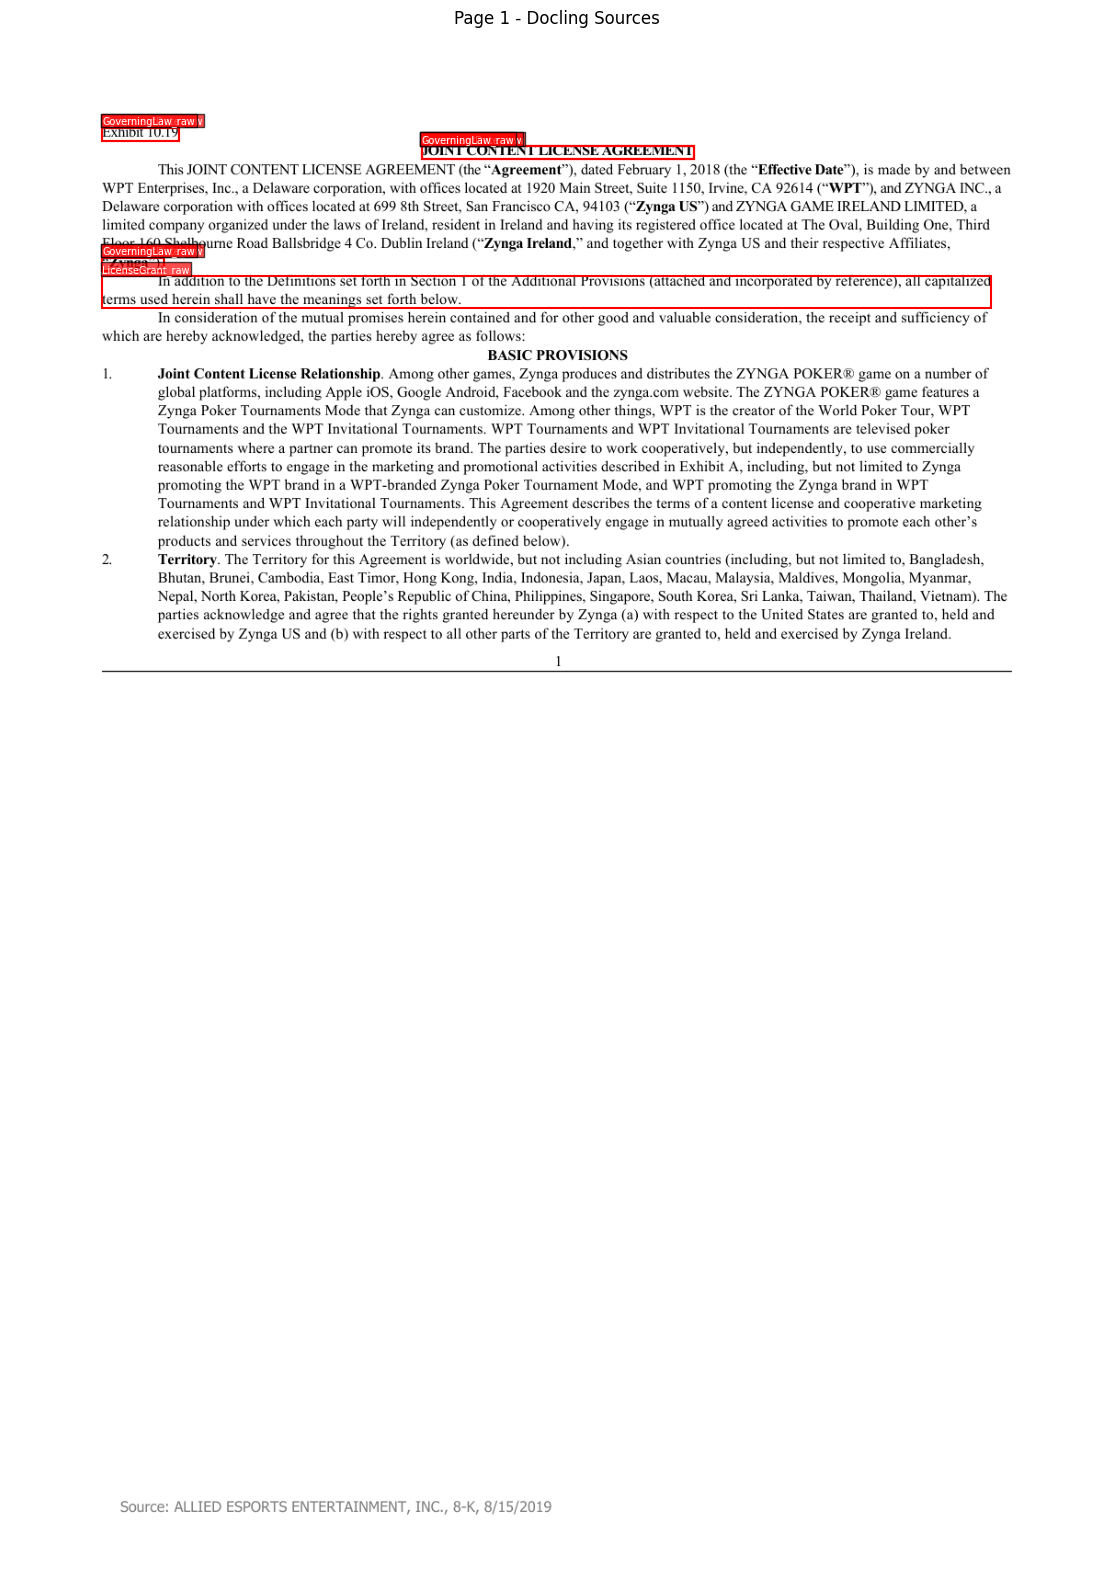

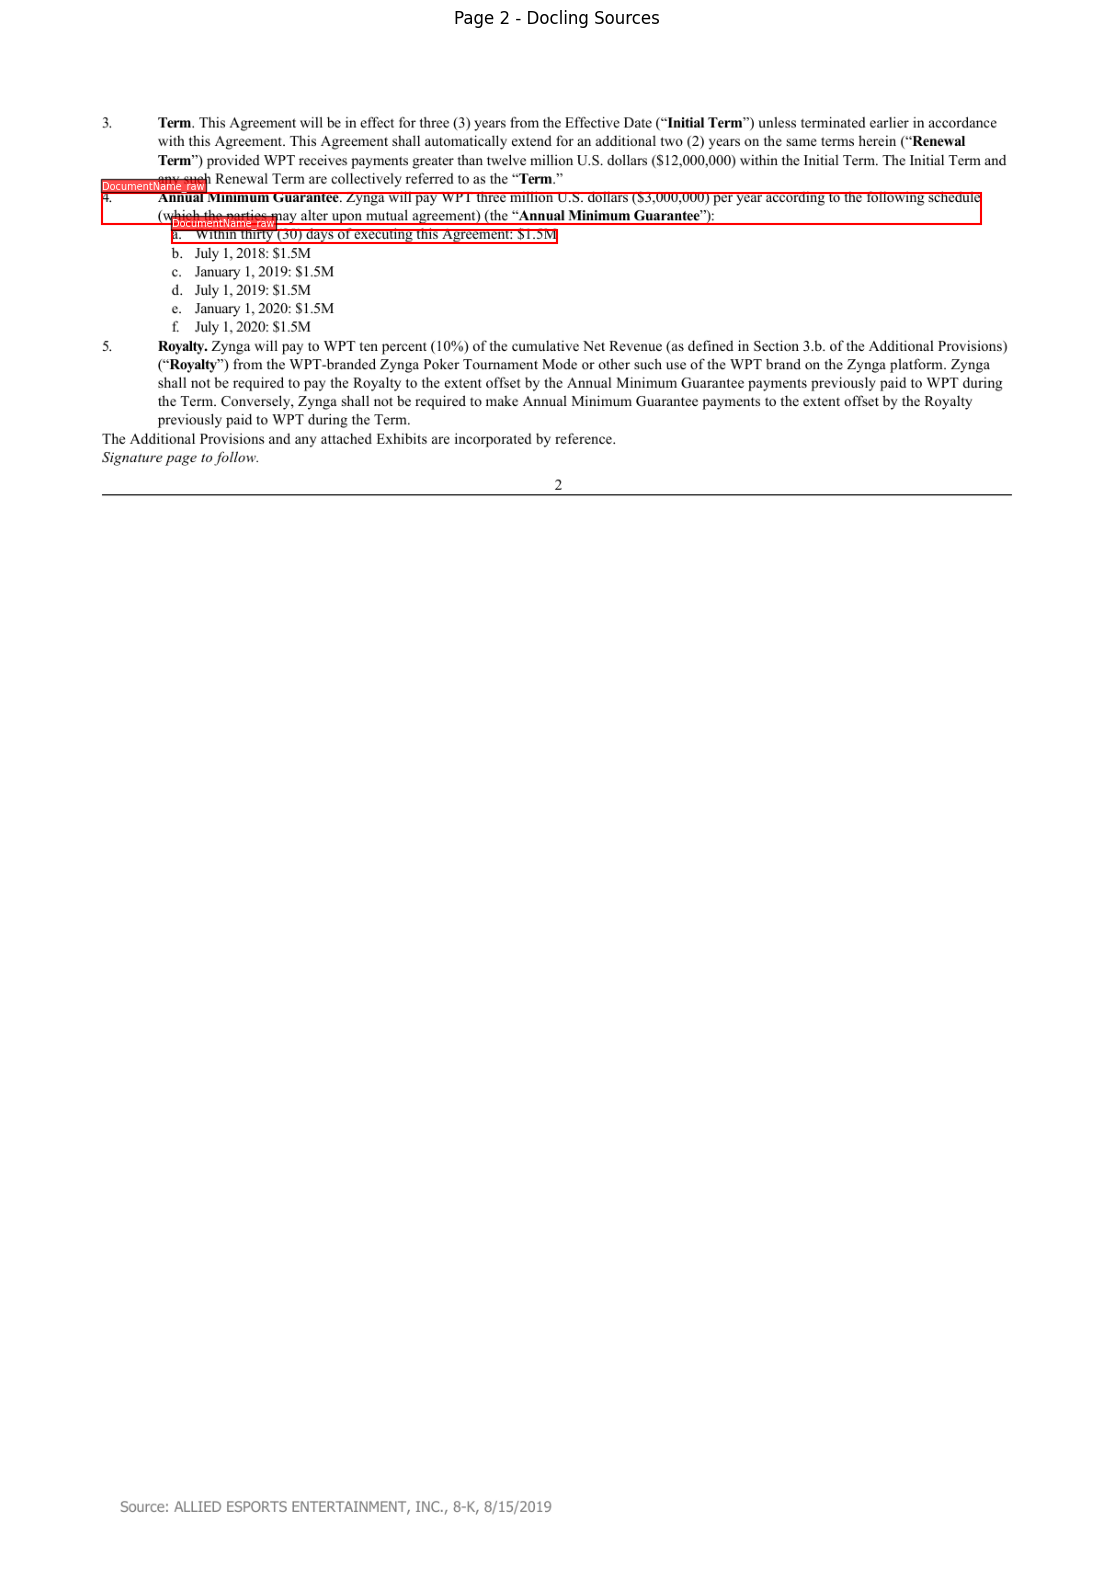

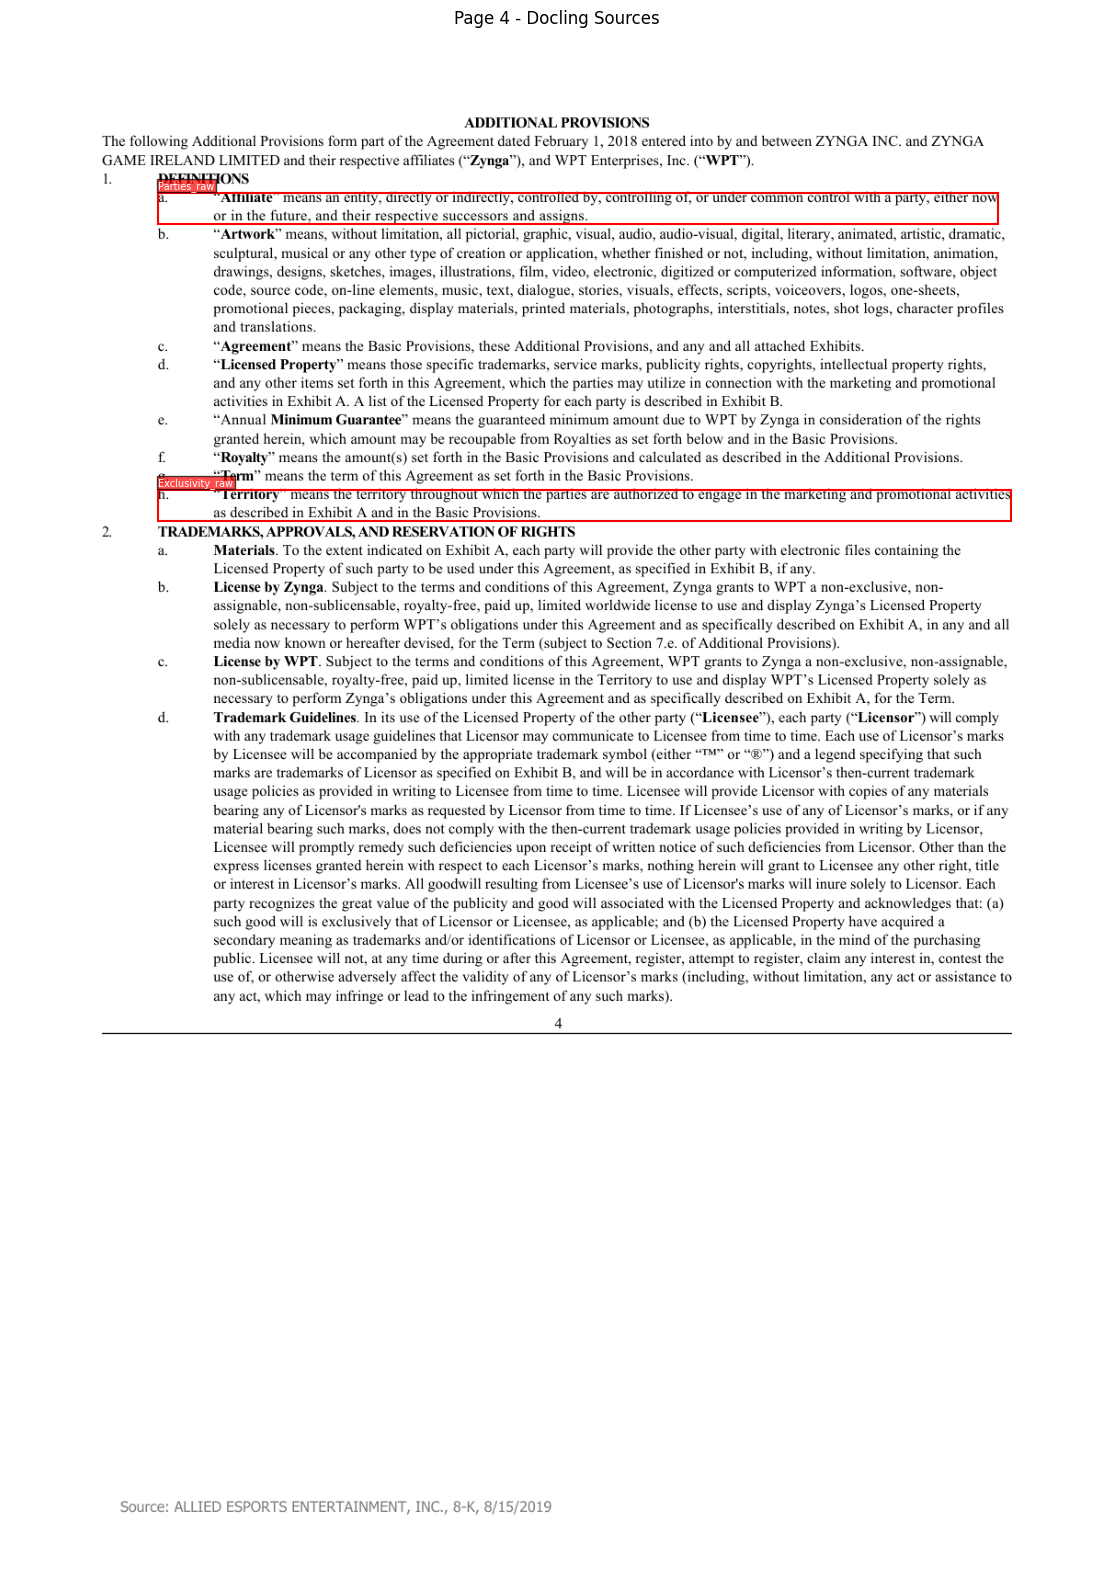

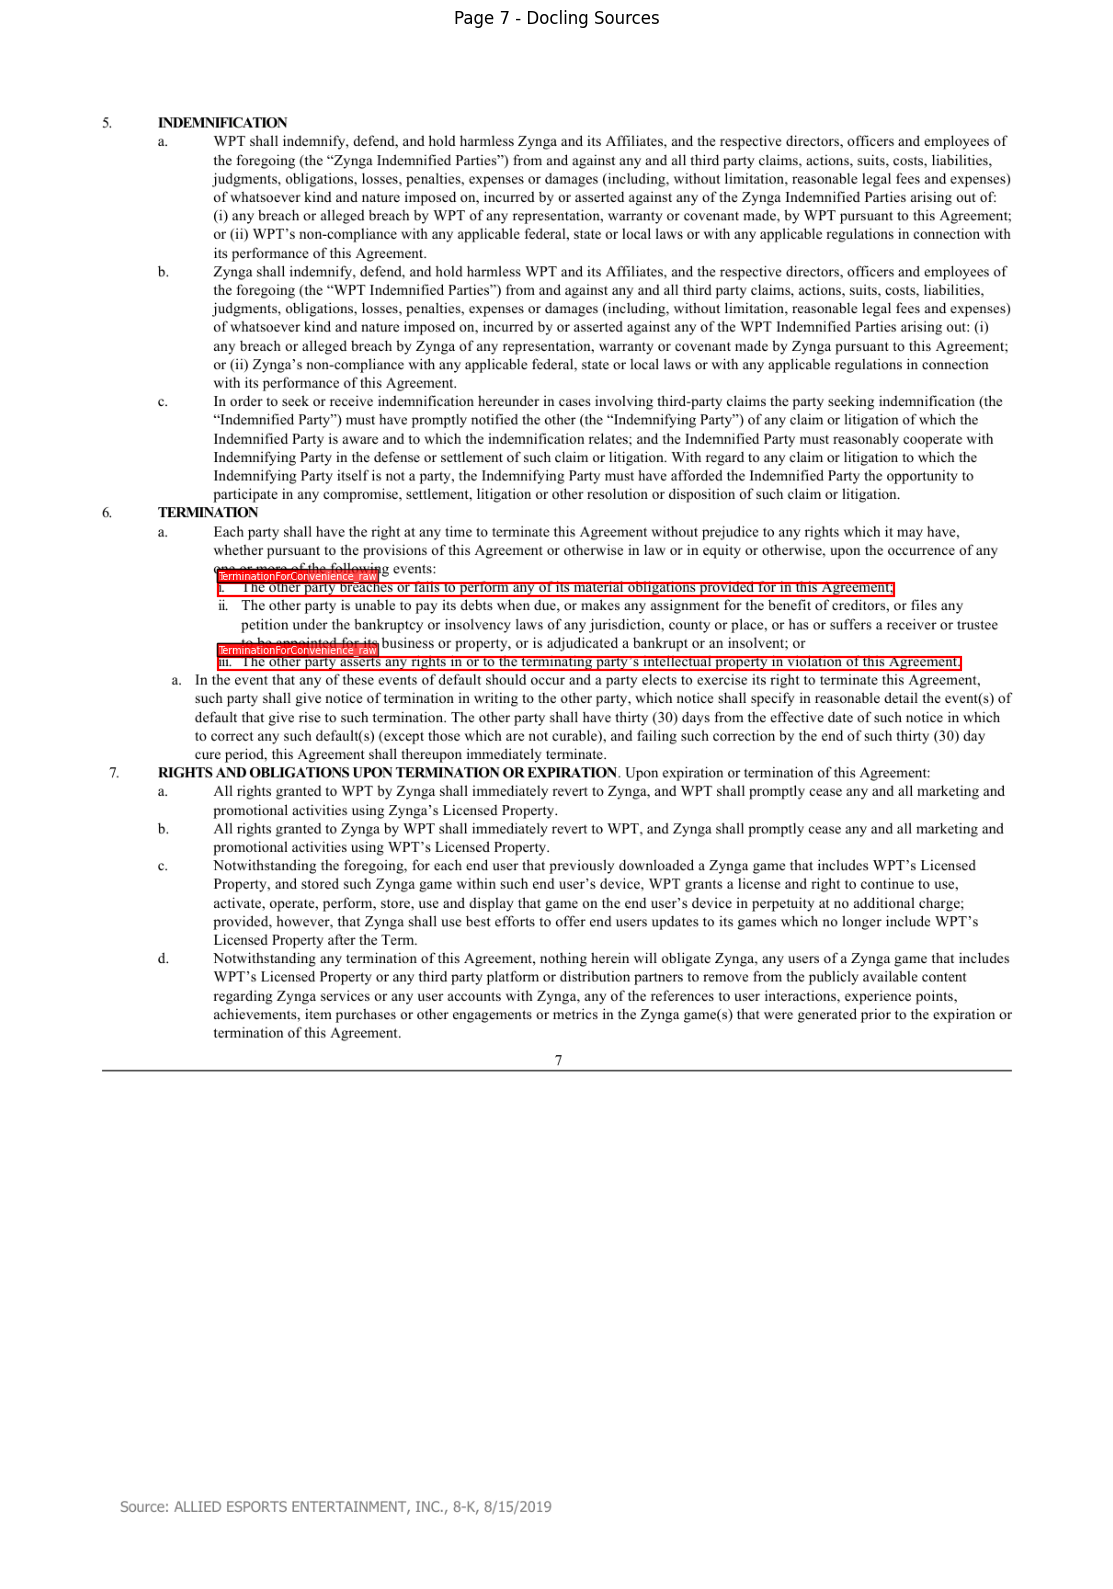

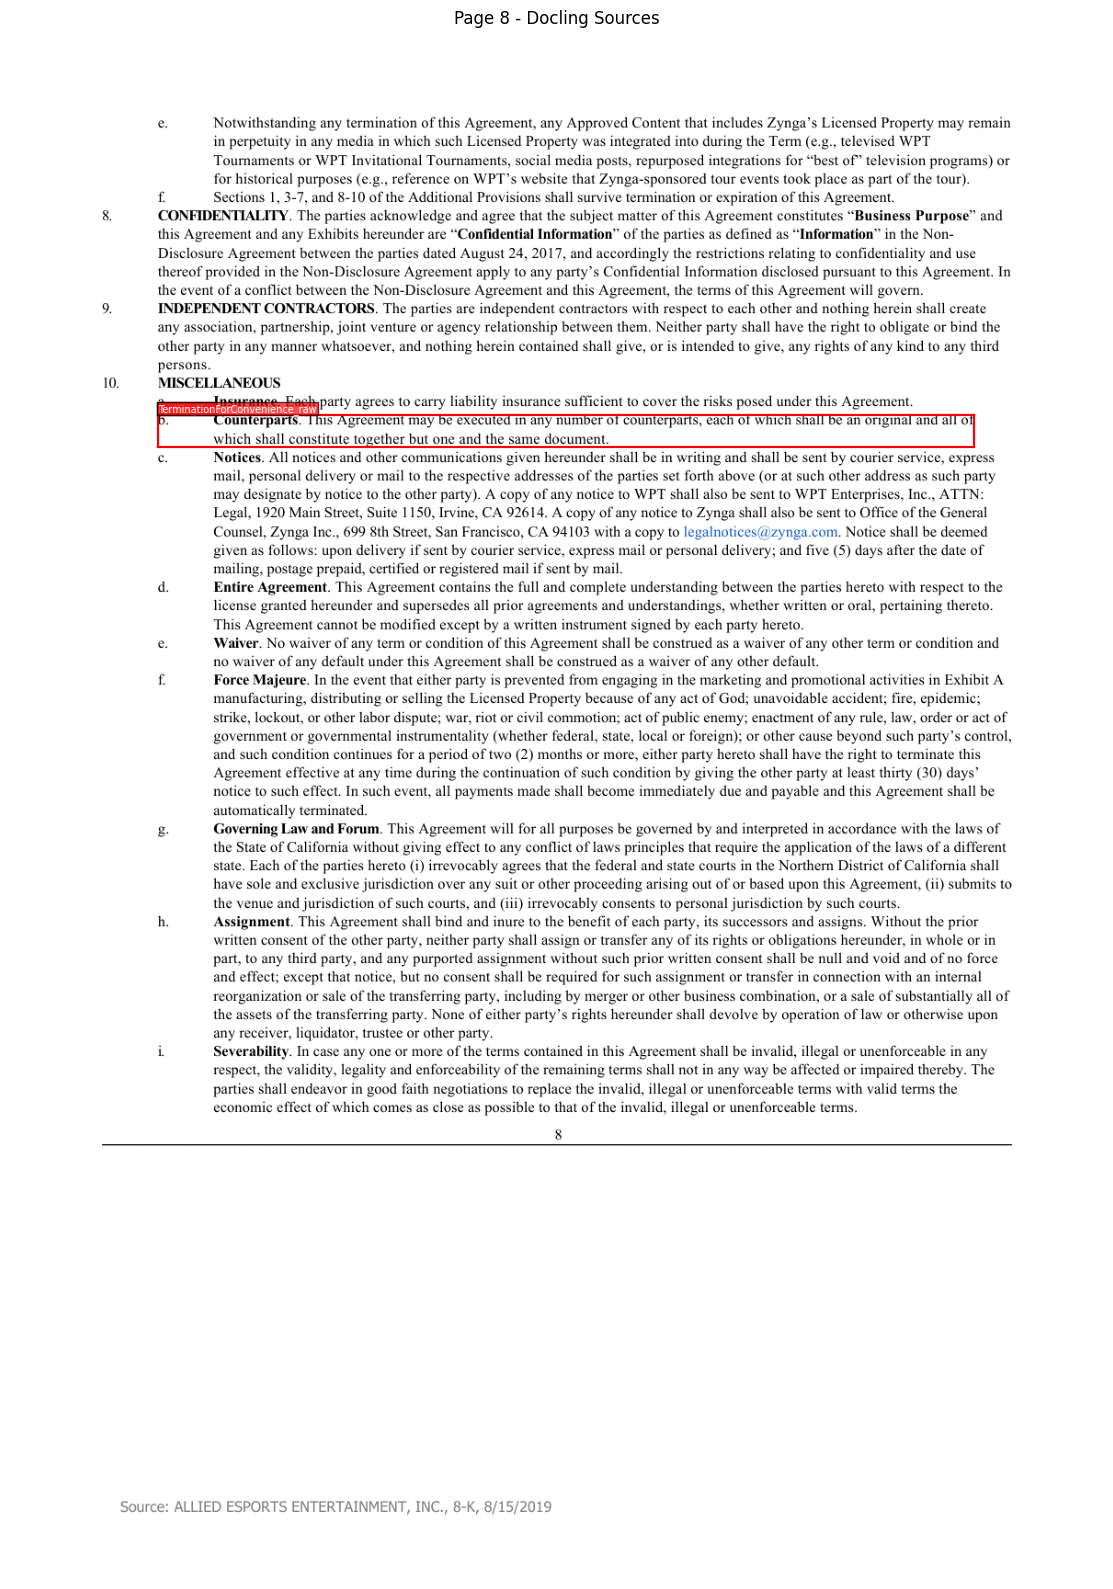

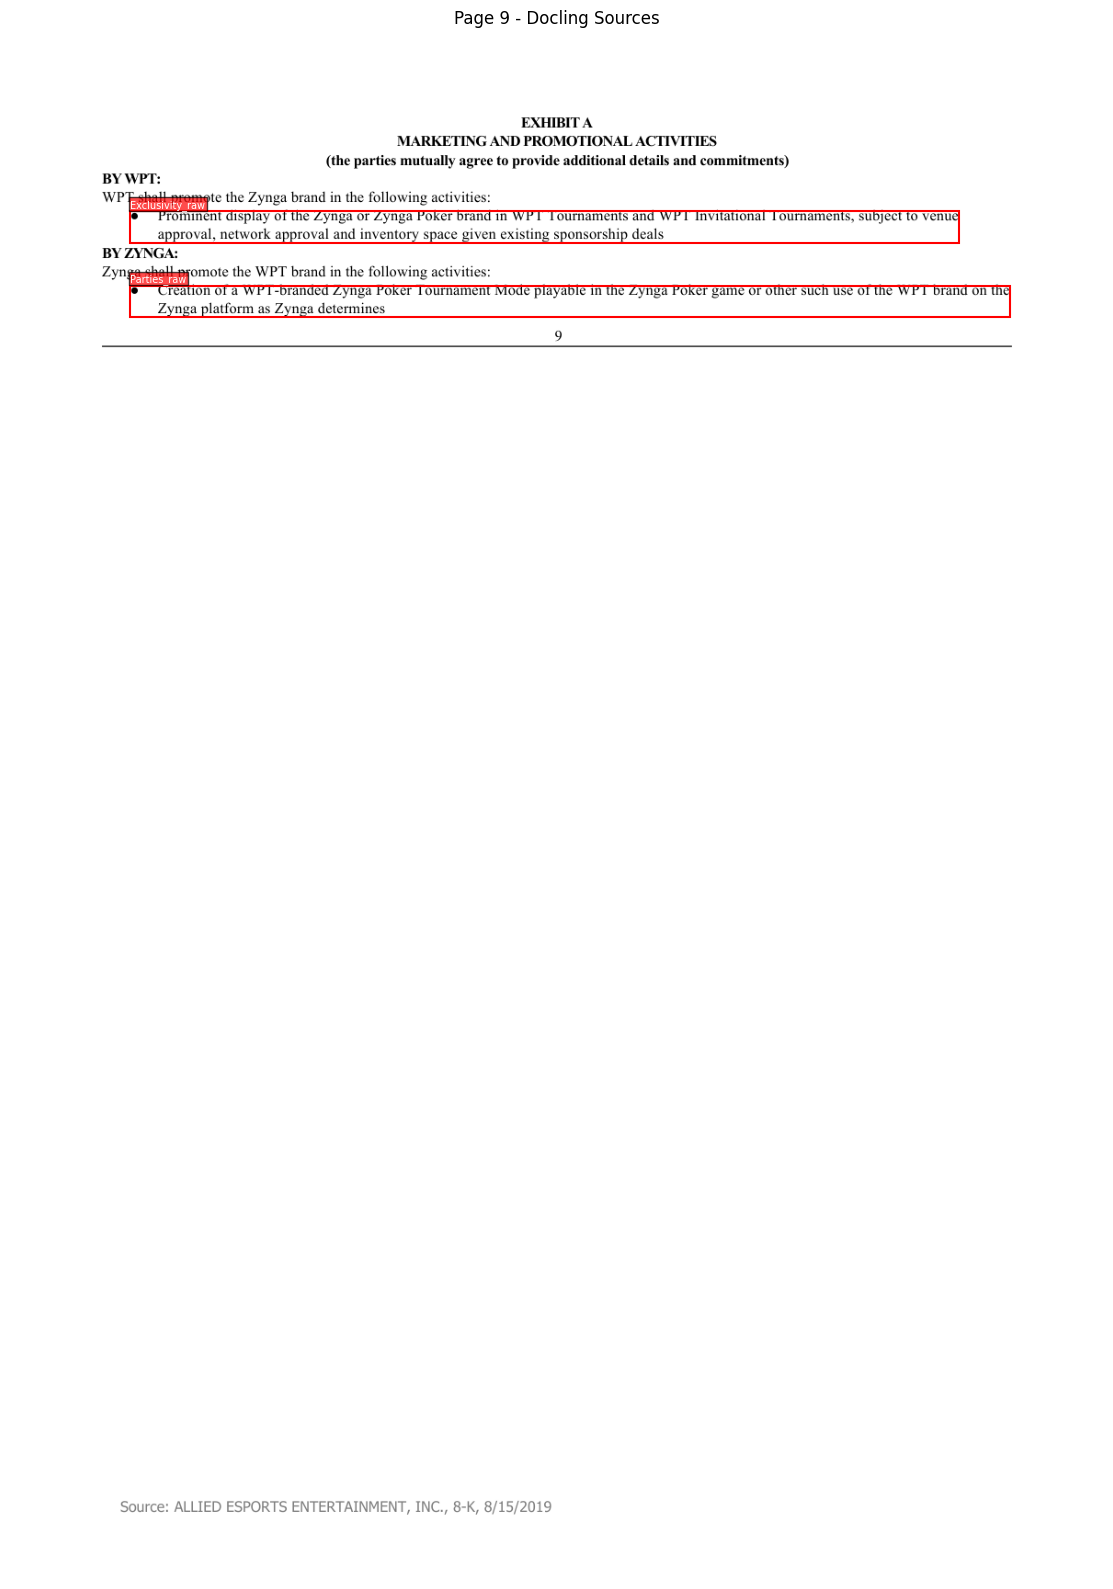

In [40]:
import io
import re
import fitz
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

def parse_d_source(d):
    m = re.match(r"D\(([^)]+)\)", d)
    if not m:
        return None
    vals = [v.strip() for v in m.group(1).split(",")]
    if len(vals) != 9:
        return None
    page = int(float(vals[0]))
    coords = list(map(float, vals[1:]))
    pts = list(zip(coords[0::2], coords[1::2]))
    return page, pts

def visualize_docling_boxes(pdf_path, canonical, zoom=2.0):
    doc = fitz.open(pdf_path)

    page_to_items = defaultdict(list)
    for field, payload in canonical["fields"].items():
        for s in payload.get("sources", []):
            parsed = parse_d_source(s.get("d_source", ""))
            if parsed:
                page_no, pts = parsed
                page_to_items[page_no].append((field, pts))

    for page_no, items in sorted(page_to_items.items()):
        page = doc[page_no - 1]
        pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), alpha=False)

        # Convert pixmap bytes -> PIL Image safely
        img = Image.open(io.BytesIO(pix.tobytes("png")))

        fig, ax = plt.subplots(figsize=(12, 16))
        ax.imshow(img)
        ax.set_title(f"Page {page_no} - Docling Sources")

        page_h = page.rect.height
        for field, pts in items:
            pts_px = [(x * zoom, (page_h - y) * zoom) for x, y in pts]
            ax.add_patch(patches.Polygon(pts_px, closed=True, fill=False, edgecolor="red", linewidth=1.5))
            ax.text(
                pts_px[0][0], max(0, pts_px[0][1] - 5), field,
                fontsize=7, color="white",
                bbox=dict(facecolor="red", alpha=0.7, pad=1),
            )

        ax.axis("off")
        plt.tight_layout()
        plt.show()

pdf_path = "data/AlliedEsportsEntertainmentInc_20190815_8-K_EX-10.19_11788293_EX-10.19_Content License Agreement.pdf"
visualize_docling_boxes(pdf_path, canonical)


## 6) POC conclusion checklist

Use this to evaluate adapter readiness:

- [ ] Structured fields extracted with acceptable quality
- [ ] Provenance nodes with bbox available
- [ ] ACU-like field contract can be generated for frontend
- [ ] Field-to-bbox mapping quality is acceptable (or needs stronger matching logic)

If this passes, next step is implementing `src/docling/` adapter behind a shared extraction interface.
